# Challenge 1: Titanic - Machine Learning from Disaster

## Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set(style="whitegrid")

## Đọc dữ liệu

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

## Preview Data

In [3]:
print('Loaded:', train.shape, test.shape)
train.head()

Loaded: (891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


## Exploratory Data Analysis - EDA

In [5]:
display(train.info())
display(train.describe())

print("\nMissing values (Train):")
print(train.isnull().mean().sort_values(ascending=False) * 100)

print("\nMissing values (Test):")
print(test.isnull().mean().sort_values(ascending=False) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing values (Train):
Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

Missing values (Test):
Cabin          78.229665
Age            20.574163
Fare            0.239234
Name            0.000000
Pclass          0.000000
PassengerId     0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Ticket          0.000000
Embarked        0.000000
dtype: float64


**Nhận xét**
- Một số cột có giá trị thiếu ở Train như Age, Cabin, Embarked.
- Một số cột có giá trị thiếu ở Test như Age, Cabin, Fare.

## Target Variable: Survived

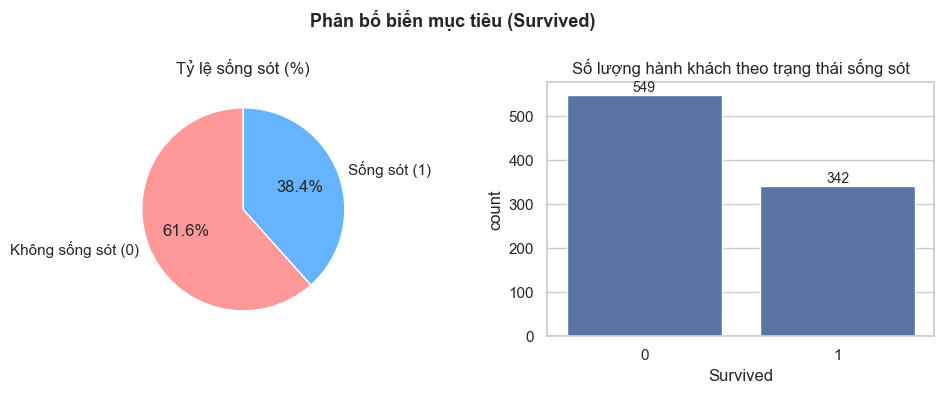

In [6]:
# Phân bố tỉ lệ sống sót
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Biểu đồ tròn
survival_counts = train['Survived'].value_counts(normalize=True)
ax[0].pie(
    survival_counts,
    labels=['Không sống sót (0)', 'Sống sót (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff']
)
ax[0].set_title('Tỷ lệ sống sót (%)')

# Biểu đồ cột
sns.countplot(x='Survived', data=train, ax=ax[1])
ax[1].set_title('Số lượng hành khách theo trạng thái sống sót')
ax[1].bar_label(ax[1].containers[0], label_type='edge', fontsize=10)

plt.suptitle('Phân bố biến mục tiêu (Survived)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét**
- Có 891 hành khách, nhưng chỉ có khoảng 38.4% sống sót (342 người).

## Phân tích dữ liệu & biểu đồ

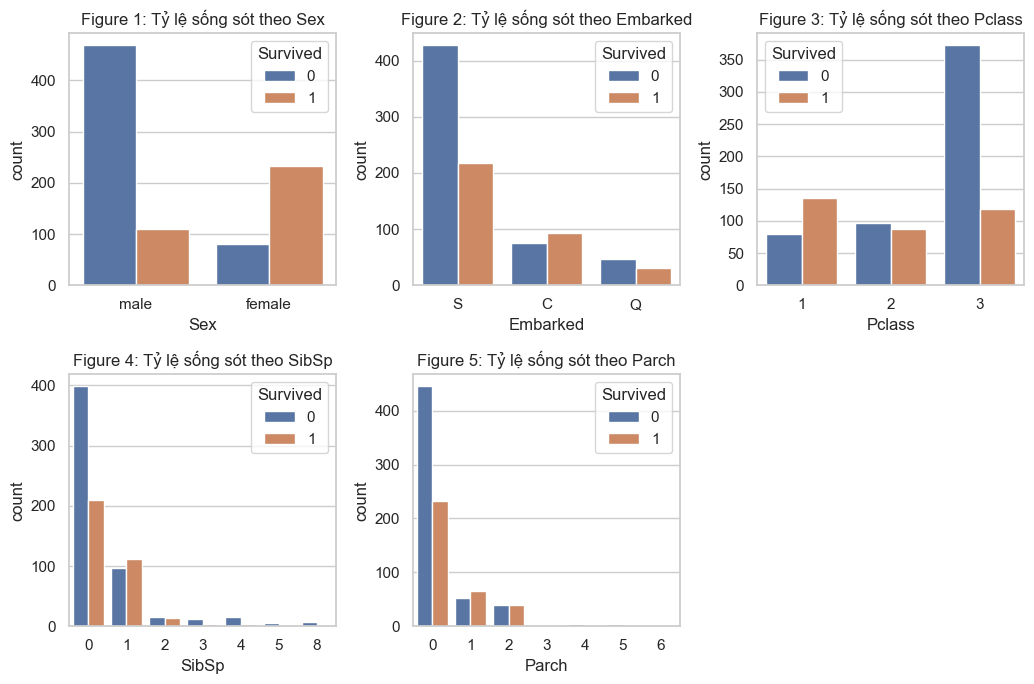

In [7]:
cols = ['Sex','Embarked', 'Pclass','SibSp','Parch']

n_rows = 2
n_cols = 3

fig, ax = plt.subplots(n_rows,n_cols, figsize=(n_cols*3.5,n_rows*3.5))

for r in range(0,n_rows):
    for c in range(0,n_cols):
        i = r*n_cols + c
        if i < len(cols):
            ax_i = ax[r,c]

            sns.countplot(data=train, x=cols[i], hue='Survived', ax=ax_i)
            ax_i.set_title(f"Figure {i+1}: Tỷ lệ sống sót theo {cols[i]}")
ax.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Figure 1: Tỷ lệ nữ giới sống sót cao hơn nam giới
- Figure 2: Đa số người lên tàu từ cảng Southampton, cũng là cảng có tỷ lệ không sống sót cao nhất
- Figure 3: Hạng vé 1 có tỷ lệ sống sót cao nhất
- Figure 4: Những người `SibSp` = 0 có tỷ lệ tử vong cao, những người có SibSp khoảng 1-2 thì có tỷ lệ sống sót cao hơn
- Figure 5: Đa số người có `Parch` = 0 cũng có tỷ lệ không sống sót cao

<Axes: xlabel='Age', ylabel='Count'>

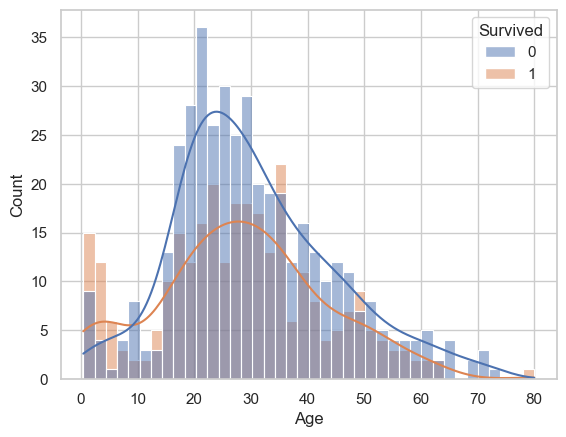

In [8]:
# Tỉ lệ sống sót theo độ tuổi
sns.histplot(data=train, x='Age', hue='Survived', bins=40, kde=True)

**Nhận xét**
- Đa phần hành khách có độ tuổi từ 18-40 tuổi.
- Trẻ em có nhiều cơ hội sống sót hơn những độ tuổi khác.

## Tiền xử lý dữ liệu (Preprocessing)

In [9]:
# Xử lý giá trị thiếu
for df in [train, test]:
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Cabin'] = df['Cabin'].fillna('Unknown')

In [10]:
from sklearn.impute import SimpleImputer

num_cols = ['Age', 'Fare']
cat_cols = ['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

## Huấn luyện các mô hình cơ bản

In [11]:
X = train.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')
y = train['Survived']
models = {
    "Logistic": LogisticRegression(max_iter=200),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    print(f"{name:15}: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic       : 0.8002 ± 0.0178
DecisionTree   : 0.7867 ± 0.0322
RandomForest   : 0.8148 ± 0.0251
XGBoost        : 0.8148 ± 0.0344
SVM            : 0.8215 ± 0.0147
GradientBoosting: 0.8171 ± 0.0183


**Nhận xét**
- Kết quả cho thấy độ chính xác các mô hình dao động quanh 0.78–0.82.

- **SVM (0.8215)** cho kết quả cao và ổn định nhất.
- Gradient Boosting và Random Forest cũng đạt hiệu suất tốt, chứng tỏ mô hình ensemble phù hợp với dữ liệu.
- Logistic Regression khá ổn, dùng làm baseline.
- Decision Tree kém hơn do dễ overfitting.
→ SVM và Gradient Boosting là hai mô hình tiềm năng nhất để tinh chỉnh thêm.

## Đánh giá từng model bằng cross-validation (trước FE)

In [12]:
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy').mean()
    f1 = cross_val_score(pipe, X, y, cv=cv, scoring='f1').mean()
    auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc').mean()

    print(f"{name} CV Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print("-" * 35)

Logistic CV Results:
  Accuracy: 0.8002
  F1 Score: 0.7306
  ROC AUC:  0.8520
-----------------------------------
DecisionTree CV Results:
  Accuracy: 0.7867
  F1 Score: 0.7259
  ROC AUC:  0.7809
-----------------------------------
RandomForest CV Results:
  Accuracy: 0.8148
  F1 Score: 0.7525
  ROC AUC:  0.8642
-----------------------------------
XGBoost CV Results:
  Accuracy: 0.8148
  F1 Score: 0.7541
  ROC AUC:  0.8656
-----------------------------------
SVM CV Results:
  Accuracy: 0.8215
  F1 Score: 0.7433
  ROC AUC:  0.8502
-----------------------------------
GradientBoosting CV Results:
  Accuracy: 0.8171
  F1 Score: 0.7393
  ROC AUC:  0.8628
-----------------------------------


## Feature Engineering (Thử nghiệm thêm đặc trưng mới)

### 1. Tạo thêm các feature mới

In [13]:
# Feature Engineering
data = train.copy()

# Family size
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# IsAlone
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# Fare per person
data['FarePerPerson'] = data['Fare'] / data['FamilySize']

# Title
data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
data['Title'] = data['Title'].replace(['Mlle','Ms'], 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')
data['Title'] = data['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)

# Deck
data['Deck'] = data['Cabin'].fillna('U').astype(str).str[0]

# Age binning + Fare binning (numeric)
data['AgeBin'] = pd.cut(data['Age'], bins=[0, 12, 20, 40, 60, 80], labels=False)
data['FareBinNum'] = pd.qcut(data['Fare'], 4, labels=False)

# AgeGroup (categorical)
data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 18, 30, 50, 80],
                          labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

# FareBin (categorical)
data['FareBin'] = pd.qcut(data['Fare'], 4, labels=['Low', 'Mid', 'High', 'VeryHigh'])

# Interaction features
data['FamilyFare'] = data['FamilySize'] * data['FarePerPerson']
data['Title_Sex'] = data['Title'] + '_' + data['Sex']

# Feature Engineering cho test dataset
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)
test['FarePerPerson'] = test['Fare'] / test['FamilySize']
test['FarePerPerson'] = test['FarePerPerson'].fillna(test['FarePerPerson'].median())

# Title
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Title'].replace(['Mlle','Ms'], 'Miss')
test['Title'] = test['Title'].replace('Mme', 'Mrs')
test['Title'] = test['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)

# Deck
test['Deck'] = test['Cabin'].fillna('U').astype(str).str[0]

# Age binning + Fare binning
test['AgeBin'] = pd.cut(test['Age'], bins=[0, 12, 20, 40, 60, 80], labels=False)
test['FareBinNum'] = pd.qcut(test['Fare'], 4, labels=False, duplicates='drop')

# AgeGroup + FareBin (categorical)
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 12, 18, 30, 50, 80],
                          labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
test['FareBin'] = pd.qcut(test['Fare'], 4, labels=['Low', 'Mid', 'High', 'VeryHigh'], duplicates='drop')

# Interaction
test['FamilyFare'] = test['FamilySize'] * test['FarePerPerson']
test['Title_Sex'] = test['Title'] + '_' + test['Sex']

print("Feature Engineering hoàn tất.")
display(data[['FamilySize','IsAlone','FarePerPerson','Title','Deck','AgeBin','FareBin','FamilyFare','Title_Sex']].head())

Feature Engineering hoàn tất.


,FamilySize,IsAlone,FarePerPerson,Title,Deck,AgeBin,FareBin,FamilyFare,Title_Sex
0,2,0,3.62500,Mr,U,2,Low,7.2500,Mr_male
1,2,0,35.64165,Mrs,C,2,VeryHigh,71.2833,Mrs_female
2,1,1,7.92500,Miss,U,2,Mid,7.9250,Miss_female
3,2,0,26.55000,Mrs,C,2,VeryHigh,53.1000,Mrs_female
4,1,1,8.05000,Mr,U,2,Mid,8.0500,Mr_male


**Nhận xét**
- FamilySize: Tổng số người trong cùng gia đình trên tàu (SibSp + Parch + 1). Giúp mô hình hiểu quy mô gia đình ảnh hưởng đến khả năng sống sót.
- IsAlone: Biến nhị phân (0/1): =1 nếu đi một mình, =0 nếu có người thân. Người đi một mình có xu hướng sống sót thấp hơn.
- FarePerPerson: Giá vé trung bình cho mỗi người trong gia đình (Fare/FamilySize). Giúp giảm ảnh hưởng của nhóm lớn trả cùng vé.
- Title: Danh xưng trích từ tên hành khách (Mr, Mrs, Miss, Master, Rare...). Thể hiện địa vị xã hội hoặc giới tính, ảnh hưởng đến khả năng được cứu.
- Deck: Boong tàu (ký tự đầu trong Cabin). Giúp mô hình nhận biết vị trí phòng — yếu tố có thể ảnh hưởng đến khả năng thoát hiểm.
- AgeBin: Nhóm tuổi được mã hóa bằng số (0–4), chia theo khoảng tuổi: Trẻ em, thiếu niên, người trẻ, trung niên, cao tuổi.
- FareBinNum: Mức giá vé được chia làm 4 nhóm theo tứ phân vị, biểu diễn dưới dạng số (0–3).
- AgeGroup: Nhóm tuổi ở dạng nhãn (Child, Teen, YoungAdult, Adult, Senior). Giúp mô hình hiểu rõ hơn từng giai đoạn tuổi.
- FareBin: Nhóm giá vé ở dạng nhãn (Low, Mid, High, VeryHigh). Phản ánh mức độ “giàu có” của hành khách.
- FamilyFare: Tương tác giữa quy mô gia đình và giá vé trung bình (FamilySize * FarePerPerson). Thể hiện khả năng chi trả của cả nhóm.
- Title_Sex: Kết hợp danh xưng và giới tính (ví dụ: “Mr_male”, “Miss_female”). Là đặc trưng mạnh để mô hình học về giới và địa vị.

In [14]:
from sklearn.preprocessing import LabelEncoder

# Các cột dạng phân loại (category)
categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck', 'AgeGroup', 'FareBin', 'Title_Sex']

# Gán giá trị mặc định cho Embarked nếu có NA
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
test['Embarked'] = test['Embarked'].fillna(data['Embarked'].mode()[0])

# Áp dụng LabelEncoder cho train và test
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(pd.concat([data[col].astype(str), test[col].astype(str)], axis=0))
    data[col] = le.transform(data[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

print("Label Encoding done.")
data[categorical_cols].head()

Label Encoding done.


,Sex,Embarked,Title,Deck,AgeGroup,FareBin,Title_Sex
0,1,2,2,8,4,1,2
1,0,0,3,2,0,3,3
2,0,2,1,8,4,2,1
3,0,2,3,2,0,3,3
4,1,2,2,8,0,2,2


In [15]:
# Chọn các cột feature để huấn luyện
feature_cols = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
    'FamilySize', 'IsAlone', 'FarePerPerson', 'Title', 'Deck',
    'AgeBin', 'FareBinNum', 'FamilyFare', 'Title_Sex',
    'AgeGroup', 'FareBin'
]

X = data[feature_cols]
y = data['Survived']

## Xử lý giá trị thiếu sau khi Feature Engineering


In [16]:
# Fill các giá trị còn thiếu
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Fare'] = data['Fare'].fillna(data['Fare'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Deck'] = data['Deck'].fillna('U')
data['FarePerPerson'] = data['FarePerPerson'].fillna(data['FarePerPerson'].median())

data = data.dropna()

print("Sau khi xử lý, tổng số giá trị thiếu còn lại:", data.isnull().sum().sum())

Sau khi xử lý, tổng số giá trị thiếu còn lại: 0


### 2. Phân tích mối tương quan giữa các feature mới với tỉ lệ sống sót

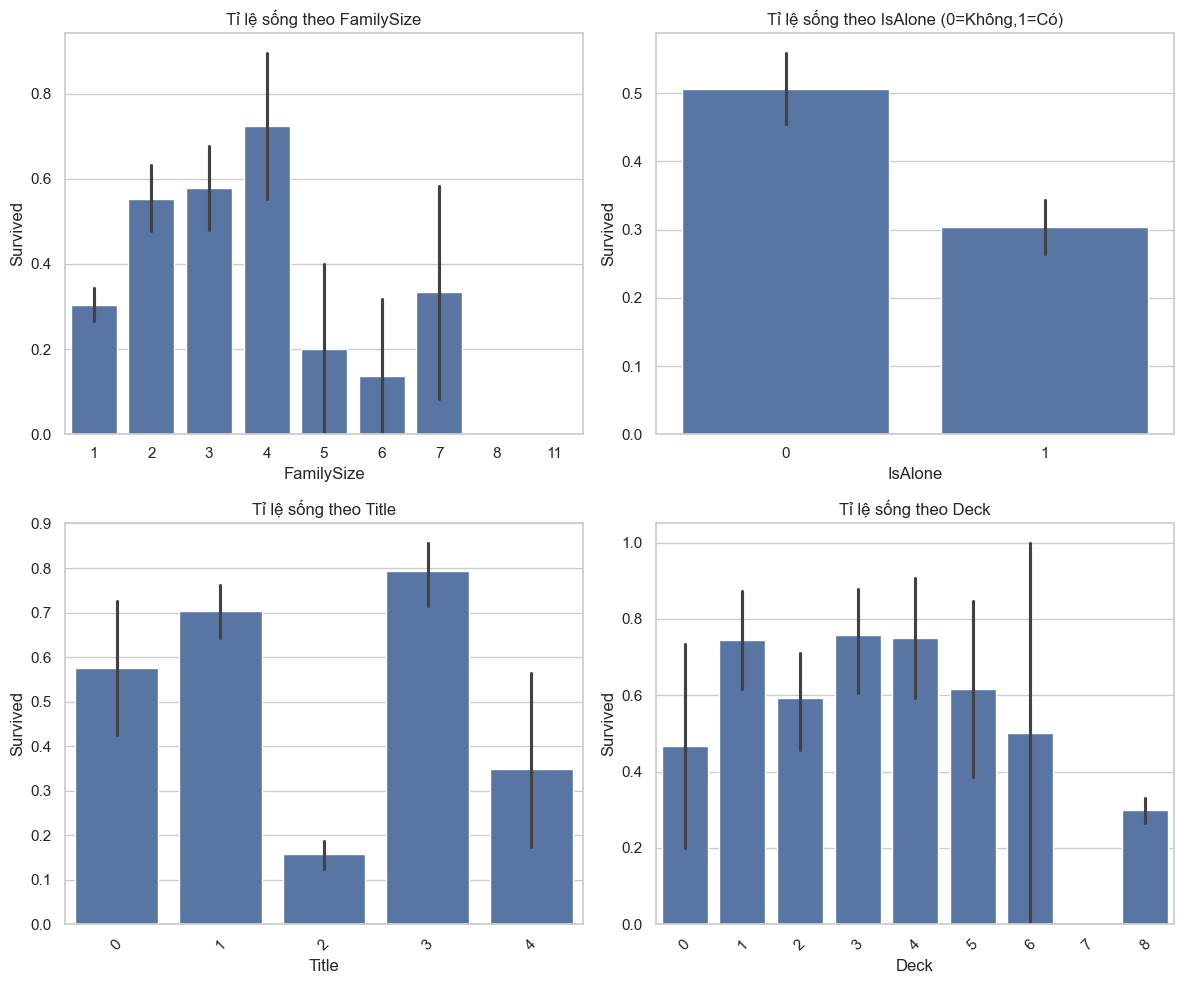

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,10))

# FamilySize vs Survival
sns.barplot(x='FamilySize', y='Survived', data=data, ax=axes[0,0])
axes[0,0].set_title('Tỉ lệ sống theo FamilySize')

# IsAlone vs Survival
sns.barplot(x='IsAlone', y='Survived', data=data, ax=axes[0,1])
axes[0,1].set_title('Tỉ lệ sống theo IsAlone (0=Không,1=Có)')

# Title vs Survival
sns.barplot(x='Title', y='Survived', data=data, ax=axes[1,0])
axes[1,0].set_title('Tỉ lệ sống theo Title')
axes[1,0].tick_params(axis='x', rotation=45)

# Deck vs Survival
sns.barplot(x='Deck', y='Survived', data=data, ax=axes[1,1])
axes[1,1].set_title('Tỉ lệ sống theo Deck')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**3. Nhận xét**
- FamilySize: Nhóm 3–4 người có tỉ lệ sống cao nhất → đi cùng vài người thân giúp tăng cơ hội sống. Người đi một mình hoặc nhóm quá đông dễ tử vong hơn.

- IsAlone: Người không đi một mình (0) sống cao hơn rõ rệt so với đi một mình (1) → hỗ trợ từ người thân quan trọng.

- Title: Phụ nữ và trẻ em (Miss, Mrs) sống cao nhất, Mr thấp nhất → phản ánh quy tắc “phụ nữ và trẻ em trước”.

- Deck: Boong B–D–E có tỉ lệ sống cao hơn, A,G và U thấp → vị trí phòng (gần boong cứu sinh) ảnh hưởng lớn đến cơ hội sống sót.

### 4. So sánh mô hình trước & sau khi thêm feature mới

In [18]:
# Chọn feature và label
X = data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = data['Survived']

# Chia cột để xử lý
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

models = {
    "Logistic": LogisticRegression(max_iter=200),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name:15}: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic       : 0.8036 ± 0.0160
DecisionTree   : 0.7856 ± 0.0340
RandomForest   : 0.8148 ± 0.0218
XGBoost        : 0.8283 ± 0.0343
SVM            : 0.8305 ± 0.0099
GradientBoosting: 0.8361 ± 0.0111


**Nhận xét**
- Mức chính xác trung bình của các mô hình tăng lên đáng kể.

- **Gradient Boosting** hiện đang là mô hình tốt nhất, đạt **~83.61%** accuracy, vượt trội hơn các mô hình còn lại.

- Việc chuẩn hóa biến số và xử lý dữ liệu phân loại hợp lý hơn đã giúp cải thiện khả năng tổng quát hóa của mô hình.

- Nhìn chung, pipeline mới giúp mô hình ổn định hơn và giảm sai lệch trong quá trình cross-validation.

In [19]:
# Tìm mô hình tốt nhất
best_model_name = max(results, key=results.get)
best_score = results[best_model_name]

print("\nBest Model:")
print(f"{best_model_name}: {best_score:.4f}")

# Huấn luyện lại mô hình tốt nhất trên toàn bộ dữ liệu
best_model = Pipeline([
    ('pre', preprocessor),
    ('model', models[best_model_name])
])
best_model.fit(X, y)

print(f"\nMô hình '{best_model_name}' đã được huấn luyện lại trên toàn bộ tập dữ liệu.")


Best Model:
GradientBoosting: 0.8361

Mô hình 'GradientBoosting' đã được huấn luyện lại trên toàn bộ tập dữ liệu.


## Đánh giá từng model bằng cross-validation (sau FE)

In [20]:
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy').mean()
    f1 = cross_val_score(pipe, X, y, cv=cv, scoring='f1').mean()
    auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc').mean()

    print(f"{name} CV Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print("-" * 35)

Logistic CV Results:
  Accuracy: 0.8036
  F1 Score: 0.7397
  ROC AUC:  0.8592
-----------------------------------
DecisionTree CV Results:
  Accuracy: 0.7856
  F1 Score: 0.7184
  ROC AUC:  0.7732
-----------------------------------
RandomForest CV Results:
  Accuracy: 0.8148
  F1 Score: 0.7572
  ROC AUC:  0.8740
-----------------------------------
XGBoost CV Results:
  Accuracy: 0.8283
  F1 Score: 0.7701
  ROC AUC:  0.8751
-----------------------------------
SVM CV Results:
  Accuracy: 0.8305
  F1 Score: 0.7705
  ROC AUC:  0.8656
-----------------------------------
GradientBoosting CV Results:
  Accuracy: 0.8361
  F1 Score: 0.7773
  ROC AUC:  0.8762
-----------------------------------


## Đánh giá từng model bằng train_test_split

In [21]:
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_val)
    y_prob = pipe.predict_proba(x_val)[:,1]

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)

    print(f"{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print("-" * 35)

Logistic Results:
  Accuracy: 0.8268
  F1 Score: 0.7891
  ROC AUC:  0.8934
-----------------------------------
DecisionTree Results:
  Accuracy: 0.7877
  F1 Score: 0.7500
  ROC AUC:  0.7917
-----------------------------------
RandomForest Results:
  Accuracy: 0.8268
  F1 Score: 0.7919
  ROC AUC:  0.9043
-----------------------------------
XGBoost Results:
  Accuracy: 0.8156
  F1 Score: 0.7692
  ROC AUC:  0.8839
-----------------------------------
SVM Results:
  Accuracy: 0.8156
  F1 Score: 0.7692
  ROC AUC:  0.8551
-----------------------------------
GradientBoosting Results:
  Accuracy: 0.8268
  F1 Score: 0.7862
  ROC AUC:  0.9029
-----------------------------------


### 5. Vẽ biểu đồ so sánh hiệu năng mô hình sau Feature Engineering

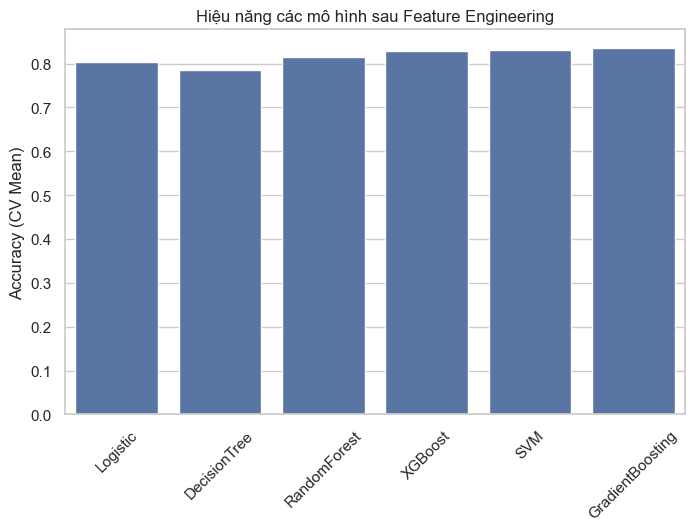

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title('Hiệu năng các mô hình sau Feature Engineering')
plt.ylabel('Accuracy (CV Mean)')
plt.xticks(rotation=45)
plt.show()

## Kết hợp mô hình (Voting Classifier)

In [23]:
# Kết hợp 3 mô hình tốt nhất: GradientBoosting, SVM, Logistic
voting_clf = VotingClassifier(
    estimators=[
        ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
        ('log', LogisticRegression(max_iter=200))
    ],
    voting='soft'
)

ensemble_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', voting_clf)
])

# Đánh giá bằng cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

acc_scores = cross_val_score(ensemble_pipe, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(ensemble_pipe, X, y, cv=cv, scoring='f1')
auc_scores = cross_val_score(ensemble_pipe, X, y, cv=cv, scoring='roc_auc')

print(f"Voting Ensemble CV Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"Voting Ensemble CV F1 Score: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"Voting Ensemble CV ROC AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

Voting Ensemble CV Accuracy: 0.8361 ± 0.0165
Voting Ensemble CV F1 Score: 0.7774 ± 0.0281
Voting Ensemble CV ROC AUC: 0.8771 ± 0.0140


**Nhận xét**
- Mô hình Voting (soft) kết hợp GradientBoosting, SVM và Logistic Regression giúp tận dụng ưu điểm khác nhau của từng mô hình: khả năng học phi tuyến mạnh của GradientBoosting, biên phân tách tốt của SVM và tính tuyến tính ổn định của Logistic.

## Huấn luyện toàn bộ & tạo submission

In [24]:
ensemble_pipe.fit(X, y)

X_test = test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')
preds = ensemble_pipe.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': preds
})
submission.to_csv("submission.csv", index=False)
print("Đã lưu file submission.csv!")

Đã lưu file submission.csv!
